In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 10, 100)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 10], initial_conditions, t_eval=time_span)

# Noise levels to consider
noise_levels = [0.0001, 0.001, 0.01, 0.1]

for noise_std in noise_levels:
    # Create synthetic noisy data
    data = sol_true.y + np.random.normal(0, noise_std, sol_true.y.shape)

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Print true and estimated mu for each noise level
    print(f"Noise level: {noise_std}")
    print(f"True mu: {mu_true}")
    print(f"Estimated mu: {mu_estimate}")
    print()


2023-08-10 01:21:41.427262: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-10 01:21:41.526972: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-08-10 01:21:41.526983: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-08-10 01:21:41.969751: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

4/4 [==============================] - 0s 954us/step
Noise level: 0.0001
True mu: 2.0
Estimated mu: 2.0006301403045654

4/4 [==============================] - 0s 878us/step
Noise level: 0.001
True mu: 2.0
Estimated mu: 2.001283884048462

4/4 [==============================] - 0s 898us/step
Noise level: 0.01
True mu: 2.0
Estimated mu: 1.9966704845428467

4/4 [==============================] - 0s 926us/step
Noise level: 0.1
True mu: 2.0
Estimated mu: 1.9938502311706543



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 10, 100)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 10], initial_conditions, t_eval=time_span)

# Noise levels to consider
noise_levels = [0.0001, 0.001, 0.01, 0.1]

for noise_std in noise_levels:
    # Create synthetic noisy data
    data = sol_true.y + np.random.normal(0, noise_std, sol_true.y.shape)

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Print the estimated mu for each noise level
    print(f"Noise level: {noise_std}")
    print(f"Estimated mu: {mu_estimate:.4f}")
    print()


4/4 [==============================] - 0s 878us/step
Noise level: 0.0001
Estimated mu: 1.9989

4/4 [==============================] - 0s 1ms/step
Noise level: 0.001
Estimated mu: 1.9988

4/4 [==============================] - 0s 1ms/step
Noise level: 0.01
Estimated mu: 2.0058

4/4 [==============================] - 0s 937us/step
Noise level: 0.1
Estimated mu: 1.9988



Epoch 1/1000
32/32 [==============================] - 1s 955us/step - loss: 0.7212
Epoch 2/1000
32/32 [==============================] - 0s 832us/step - loss: 0.0623
Epoch 3/1000
32/32 [==============================] - 0s 964us/step - loss: 0.0319
Epoch 4/1000
32/32 [==============================] - 0s 953us/step - loss: 0.0263
Epoch 5/1000
32/32 [==============================] - 0s 975us/step - loss: 0.0216
Epoch 6/1000
32/32 [==============================] - 0s 1ms/step - loss: 0.0178
Epoch 7/1000
32/32 [==============================] - 0s 963us/step - loss: 0.0150
Epoch 8/1000
32/32 [==============================] - 0s 921us/step - loss: 0.0131
Epoch 9/1000
32/32 [==============================] - 0s 977us/step - loss: 0.0115
Epoch 10/1000
32/32 [==============================] - 0s 962us/step - loss: 0.0101
Epoch 11/1000
32/32 [==============================] - 0s 957us/step - loss: 0.0093
Epoch 12/1000
32/32 [==============================] - 0s 1ms/step - loss: 0.0082
Epoch

32/32 [==============================] - 0s 1ms/step - loss: 3.5115e-05
Epoch 98/1000
32/32 [==============================] - 0s 938us/step - loss: 3.6687e-05
Epoch 99/1000
32/32 [==============================] - 0s 929us/step - loss: 3.2132e-05
Epoch 100/1000
32/32 [==============================] - 0s 959us/step - loss: 3.2091e-05
Epoch 101/1000
32/32 [==============================] - 0s 888us/step - loss: 4.4057e-05
Epoch 102/1000
32/32 [==============================] - 0s 905us/step - loss: 3.7599e-05
Epoch 103/1000
32/32 [==============================] - 0s 919us/step - loss: 3.7890e-05
Epoch 104/1000
32/32 [==============================] - 0s 886us/step - loss: 4.0775e-05
Epoch 105/1000
32/32 [==============================] - 0s 1ms/step - loss: 4.1819e-05
Epoch 106/1000
32/32 [==============================] - 0s 985us/step - loss: 3.9463e-05
Epoch 107/1000
32/32 [==============================] - 0s 963us/step - loss: 4.2229e-05
Epoch 108/1000
32/32 [====================

32/32 [==============================] - 0s 962us/step - loss: 9.4774e-05
Epoch 190/1000
32/32 [==============================] - 0s 932us/step - loss: 4.0084e-05
Epoch 191/1000
32/32 [==============================] - 0s 937us/step - loss: 4.3566e-05
Epoch 192/1000
32/32 [==============================] - 0s 928us/step - loss: 2.4656e-05
Epoch 193/1000
32/32 [==============================] - 0s 920us/step - loss: 1.1359e-05
Epoch 194/1000
32/32 [==============================] - 0s 936us/step - loss: 1.6077e-05
Epoch 195/1000
32/32 [==============================] - 0s 964us/step - loss: 1.2296e-05
Epoch 196/1000
32/32 [==============================] - 0s 921us/step - loss: 1.1492e-05
Epoch 197/1000
32/32 [==============================] - 0s 973us/step - loss: 1.1193e-05
Epoch 198/1000
32/32 [==============================] - 0s 986us/step - loss: 1.2840e-05
Epoch 199/1000
32/32 [==============================] - 0s 988us/step - loss: 1.1776e-05
Epoch 200/1000
32/32 [==============

32/32 [==============================] - 0s 1ms/step - loss: 7.8439e-06
Epoch 282/1000
32/32 [==============================] - 0s 1ms/step - loss: 8.0477e-06
Epoch 283/1000
32/32 [==============================] - 0s 970us/step - loss: 4.3845e-05
Epoch 284/1000
32/32 [==============================] - 0s 926us/step - loss: 3.1371e-05
Epoch 285/1000
32/32 [==============================] - 0s 961us/step - loss: 1.6183e-05
Epoch 286/1000
32/32 [==============================] - 0s 930us/step - loss: 1.3294e-05
Epoch 287/1000
32/32 [==============================] - 0s 944us/step - loss: 1.4651e-05
Epoch 288/1000
32/32 [==============================] - 0s 946us/step - loss: 4.0073e-05
Epoch 289/1000
32/32 [==============================] - 0s 947us/step - loss: 4.9077e-05
Epoch 290/1000
32/32 [==============================] - 0s 963us/step - loss: 3.9307e-05
Epoch 291/1000
32/32 [==============================] - 0s 947us/step - loss: 3.5323e-05
Epoch 292/1000
32/32 [==================

32/32 [==============================] - 0s 987us/step - loss: 1.1294e-05
Epoch 374/1000
32/32 [==============================] - 0s 960us/step - loss: 5.7923e-06
Epoch 375/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.1536e-05
Epoch 376/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.0928e-05
Epoch 377/1000
32/32 [==============================] - 0s 970us/step - loss: 7.6979e-06
Epoch 378/1000
32/32 [==============================] - 0s 960us/step - loss: 6.4748e-06
Epoch 379/1000
32/32 [==============================] - 0s 910us/step - loss: 4.5766e-06
Epoch 380/1000
32/32 [==============================] - 0s 896us/step - loss: 7.8764e-06
Epoch 381/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.1535e-05
Epoch 382/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.0735e-04
Epoch 383/1000
32/32 [==============================] - 0s 1ms/step - loss: 9.2340e-05
Epoch 384/1000
32/32 [========================

...

Epoch 561/1000
32/32 [==============================] - 0s 917us/step - loss: 1.9372e-06
Epoch 562/1000
32/32 [==============================] - 0s 946us/step - loss: 1.6409e-06
Epoch 563/1000
32/32 [==============================] - 0s 942us/step - loss: 3.3822e-06
Epoch 564/1000
32/32 [==============================] - 0s 949us/step - loss: 3.0935e-06
Epoch 565/1000
32/32 [==============================] - 0s 946us/step - loss: 9.9869e-06
Epoch 566/1000
32/32 [==============================] - 0s 906us/step - loss: 1.6534e-05
Epoch 567/1000
32/32 [==============================] - 0s 914us/step - loss: 1.5347e-05
Epoch 568/1000
32/32 [==============================] - 0s 978us/step - loss: 7.9742e-06
Epoch 569/1000
32/32 [==============================] - 0s 936us/step - loss: 2.7250e-06
Epoch 570/1000
32/32 [==============================] - 0s 925us/step - loss: 4.6363e-06
Epoch 571/1000
32/32 [==============================] - 0s 926us/step - loss: 2.4524e-06
Epoch 572/1000
32/32 

32/32 [==============================] - 0s 1ms/step - loss: 3.0176e-06
Epoch 655/1000
32/32 [==============================] - 0s 1ms/step - loss: 4.0852e-06
Epoch 656/1000
32/32 [==============================] - 0s 1ms/step - loss: 3.5897e-06
Epoch 657/1000
32/32 [==============================] - 0s 1ms/step - loss: 3.4566e-06
Epoch 658/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.4177e-06
Epoch 659/1000
32/32 [==============================] - 0s 1ms/step - loss: 5.4156e-06
Epoch 660/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.6063e-06
Epoch 661/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.4876e-06
Epoch 662/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.7517e-06
Epoch 663/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.1546e-06
Epoch 664/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.2745e-06
Epoch 665/1000
32/32 [==============================] - 0s

32/32 [==============================] - 0s 993us/step - loss: 1.4400e-06
Epoch 748/1000
32/32 [==============================] - 0s 996us/step - loss: 2.3725e-06
Epoch 749/1000
32/32 [==============================] - 0s 994us/step - loss: 2.6587e-06
Epoch 750/1000
32/32 [==============================] - 0s 949us/step - loss: 3.5596e-06
Epoch 751/1000
32/32 [==============================] - 0s 980us/step - loss: 1.3686e-05
Epoch 752/1000
32/32 [==============================] - 0s 939us/step - loss: 8.7800e-06
Epoch 753/1000
32/32 [==============================] - 0s 959us/step - loss: 4.1379e-06
Epoch 754/1000
32/32 [==============================] - 0s 970us/step - loss: 1.9950e-06
Epoch 755/1000
32/32 [==============================] - 0s 987us/step - loss: 1.7497e-06
Epoch 756/1000
32/32 [==============================] - 0s 955us/step - loss: 2.1568e-06
Epoch 757/1000
32/32 [==============================] - 0s 951us/step - loss: 1.4041e-06
Epoch 758/1000
32/32 [==============

32/32 [==============================] - 0s 980us/step - loss: 4.6402e-06
Epoch 841/1000
32/32 [==============================] - 0s 1ms/step - loss: 3.6079e-06
Epoch 842/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.0215e-06
Epoch 843/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.8801e-06
Epoch 844/1000
32/32 [==============================] - 0s 1ms/step - loss: 4.5842e-06
Epoch 845/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.3544e-05
Epoch 846/1000
32/32 [==============================] - 0s 1ms/step - loss: 6.1595e-05
Epoch 847/1000
32/32 [==============================] - 0s 999us/step - loss: 3.6307e-05
Epoch 848/1000
32/32 [==============================] - 0s 1ms/step - loss: 1.0123e-05
Epoch 849/1000
32/32 [==============================] - 0s 1ms/step - loss: 2.9437e-06
Epoch 850/1000
32/32 [==============================] - 0s 993us/step - loss: 3.2019e-06
Epoch 851/1000
32/32 [==============================

32/32 [==============================] - 0s 1ms/step - loss: 2.4846e-06
Epoch 934/1000
32/32 [==============================] - 0s 1ms/step - loss: 7.2937e-06
Epoch 935/1000
32/32 [==============================] - 0s 980us/step - loss: 2.9264e-05
Epoch 936/1000
32/32 [==============================] - 0s 1ms/step - loss: 3.6503e-05
Epoch 937/1000
32/32 [==============================] - 0s 940us/step - loss: 8.5568e-06
Epoch 938/1000
32/32 [==============================] - 0s 994us/step - loss: 4.8351e-06
Epoch 939/1000
32/32 [==============================] - 0s 993us/step - loss: 2.8141e-06
Epoch 940/1000
32/32 [==============================] - 0s 999us/step - loss: 3.6854e-06
Epoch 941/1000
32/32 [==============================] - 0s 974us/step - loss: 9.3416e-06
Epoch 942/1000
32/32 [==============================] - 0s 1ms/step - loss: 8.9058e-06
Epoch 943/1000
32/32 [==============================] - 0s 989us/step - loss: 1.0669e-05
Epoch 944/1000
32/32 [======================

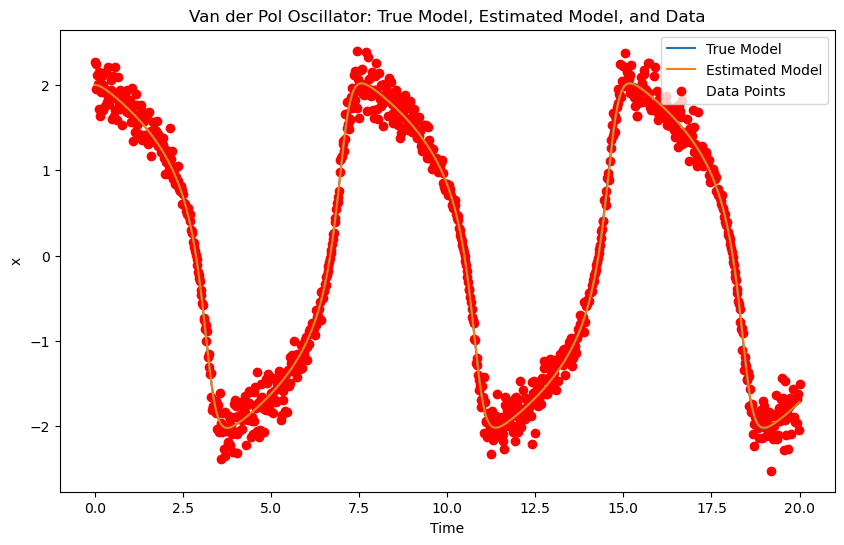

True mu: 2.0
Estimated mu: 1.9988704919815063


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Create synthetic noisy data with multiplicative noise
noise_std = 0.1
multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
data = sol_true.y * multiplicative_noise

# Define the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
])

# Compile the model with Huber loss
huber_loss = tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=huber_loss)

# Train the neural network
model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=1)

# Predict the estimated parameter using the trained neural network
mu_estimate = model.predict(data.T).mean()

# Solve with true and estimated parameters
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

# Plot true model, estimated model, and data points
plt.figure(figsize=(10, 6))

plt.plot(sol_true.t, sol_true.y[0], label='True Model')
plt.plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
plt.scatter(time_span, data[0], color='red', marker='o', label='Data Points')
plt.xlabel('Time')
plt.ylabel('x')
plt.title('Van der Pol Oscillator: True Model, Estimated Model, and Data')
plt.legend()

plt.show()

print(f"True mu: {mu_true}")
print(f"Estimated mu: {mu_estimate}")


32/32 [==============================] - 0s 820us/step


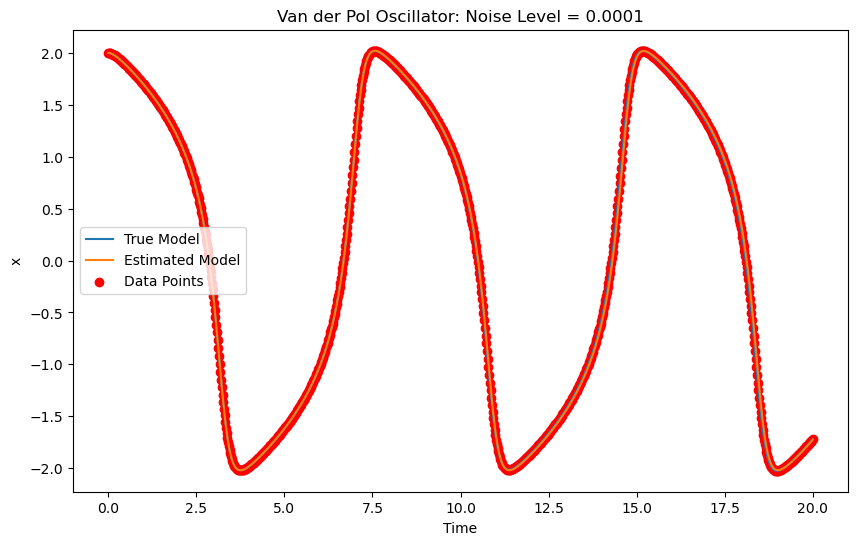

Noise Level: 0.0001
Estimated mu: 2.0018458366394043
------
32/32 [==============================] - 0s 701us/step


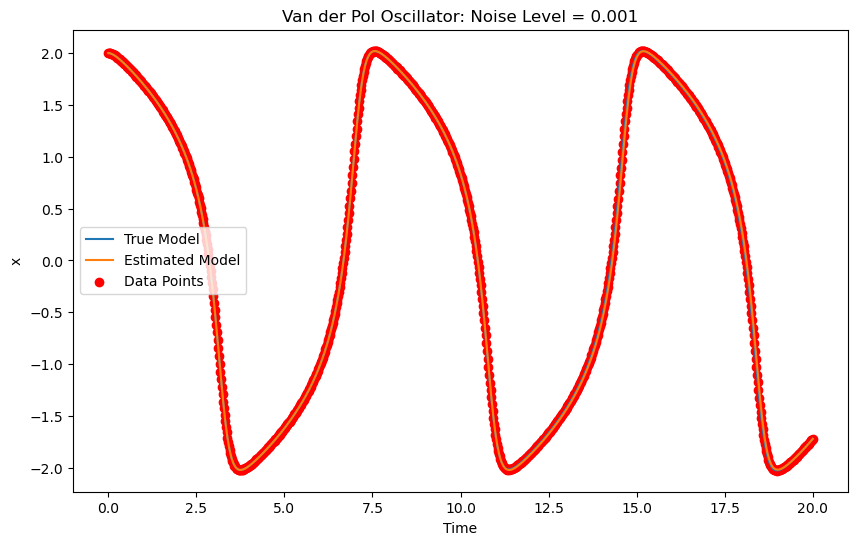

Noise Level: 0.001
Estimated mu: 1.9996086359024048
------
32/32 [==============================] - 0s 689us/step


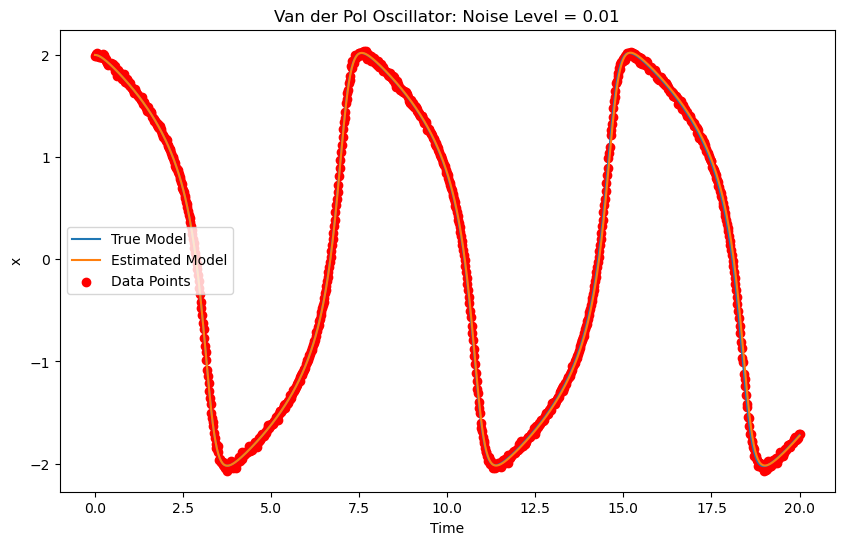

Noise Level: 0.01
Estimated mu: 2.001523971557617
------
32/32 [==============================] - 0s 680us/step


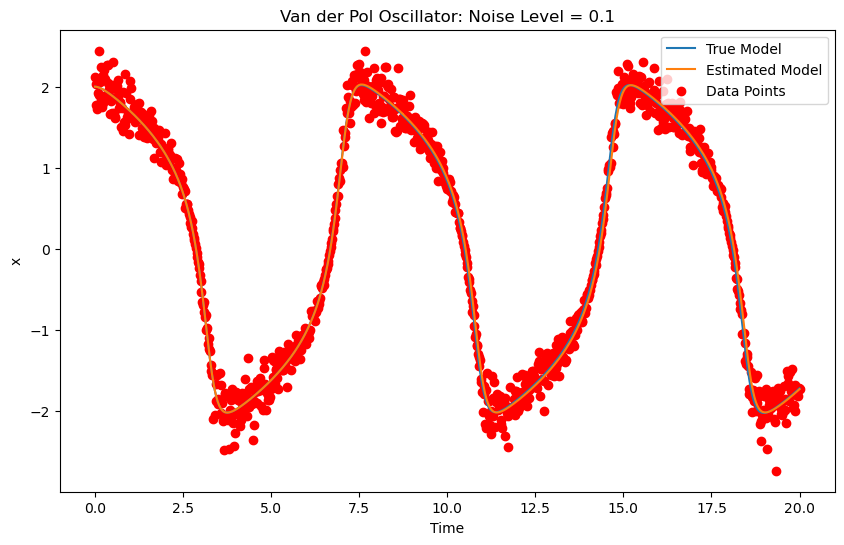

Noise Level: 0.1
Estimated mu: 2.0016345977783203
------


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

for noise_std in noise_levels:
    # Create synthetic noisy data with multiplicative noise
    multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
    data = sol_true.y * multiplicative_noise

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Solve with true and estimated parameters
    sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
    sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

    # Plot true model, estimated model, and data points
    plt.figure(figsize=(10, 6))

    plt.plot(sol_true.t, sol_true.y[0], label='True Model')
    plt.plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
    plt.scatter(time_span, data[0], color='red', marker='o', label='Data Points')
    plt.xlabel('Time')
    plt.ylabel('x')
    plt.title(f'Van der Pol Oscillator: Noise Level = {noise_std}')
    plt.legend()

    plt.show()

    print(f"Noise Level: {noise_std}")
    print(f"Estimated mu: {mu_estimate}")
    print("------")


32/32 [==============================] - 0s 664us/step


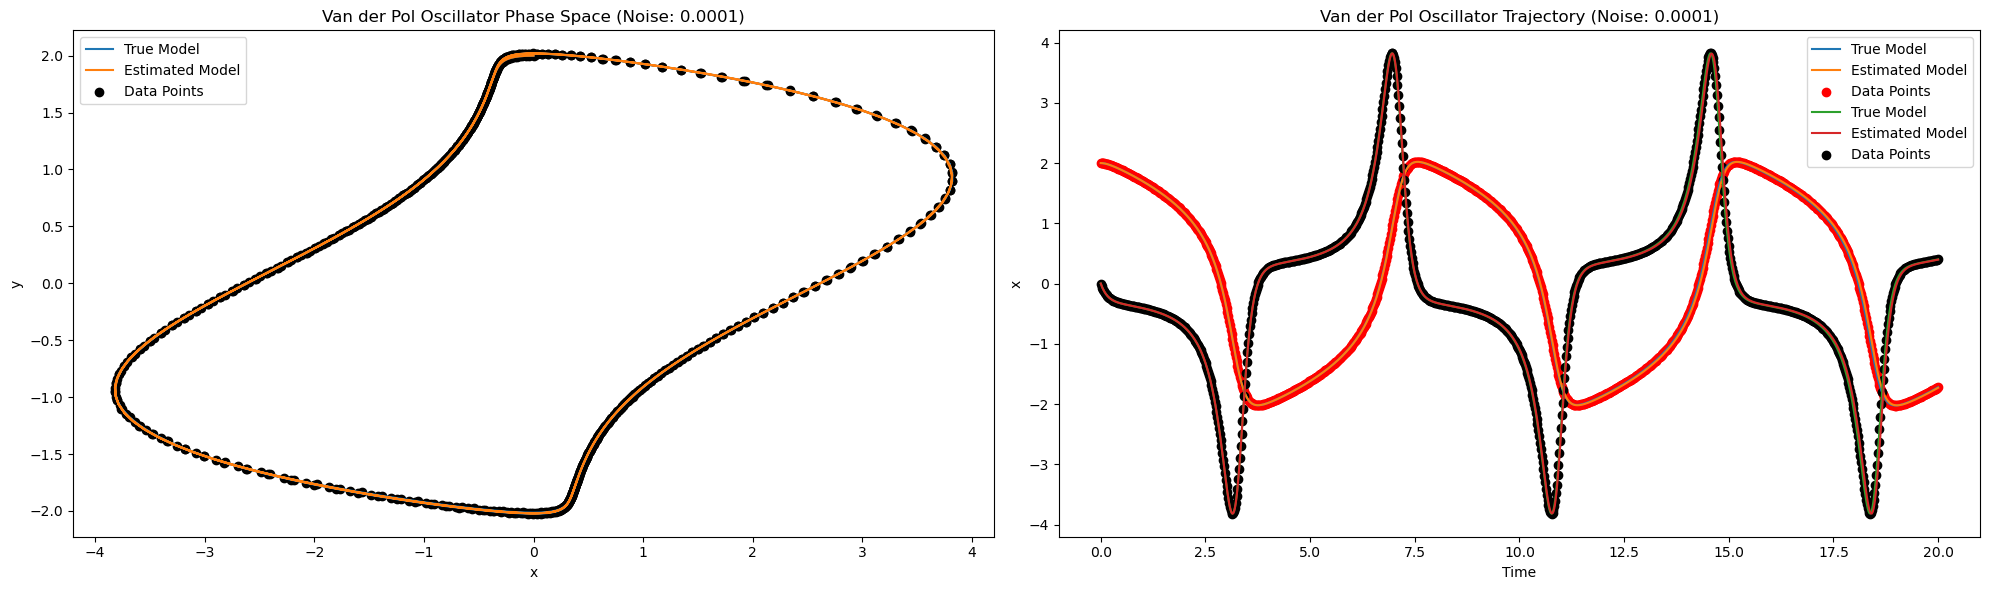

Noise Level: 0.0001
Estimated mu: 2.0023486614227295
------
32/32 [==============================] - 0s 744us/step


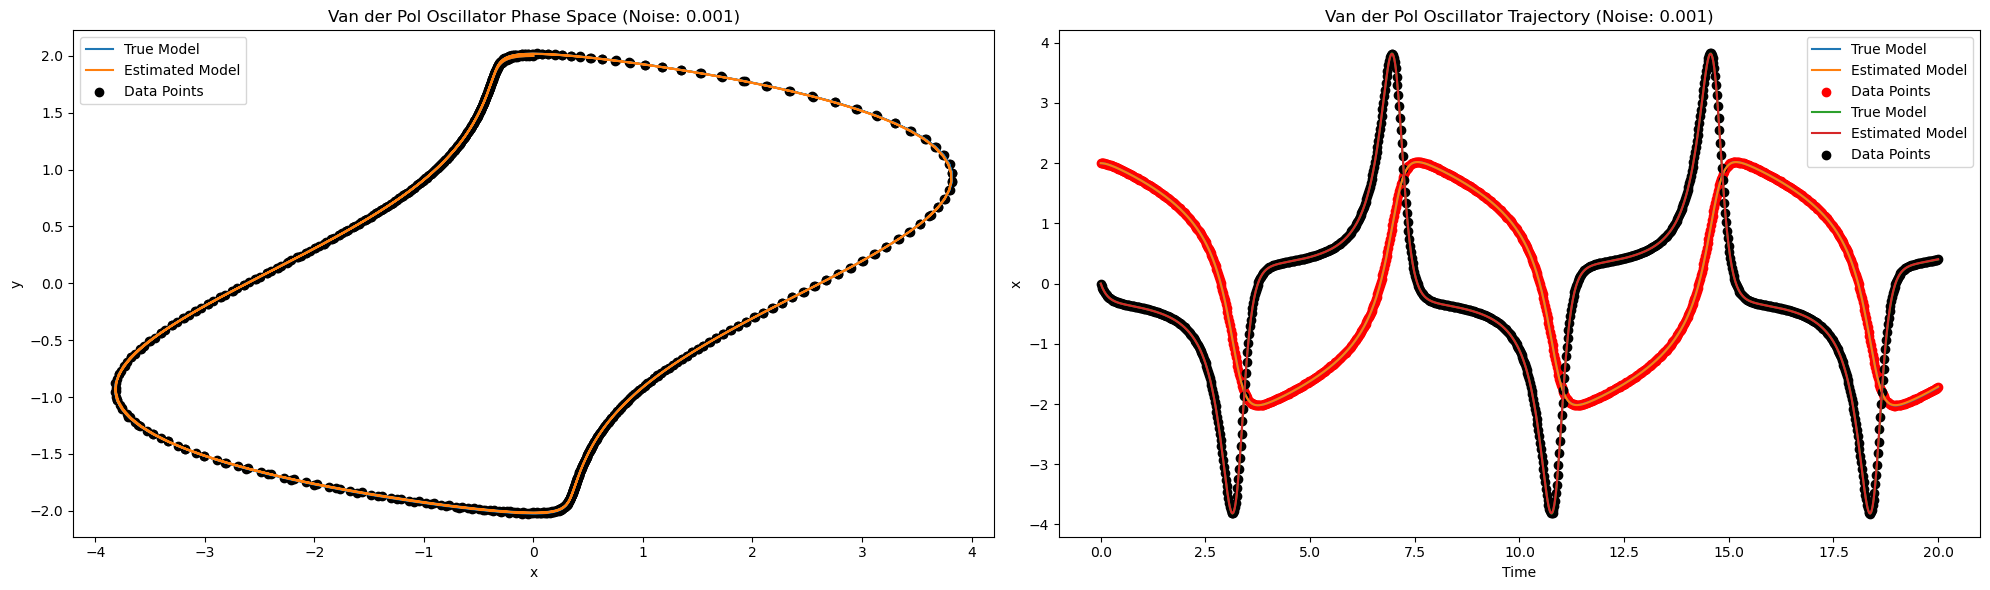

Noise Level: 0.001
Estimated mu: 1.9975649118423462
------
32/32 [==============================] - 0s 811us/step


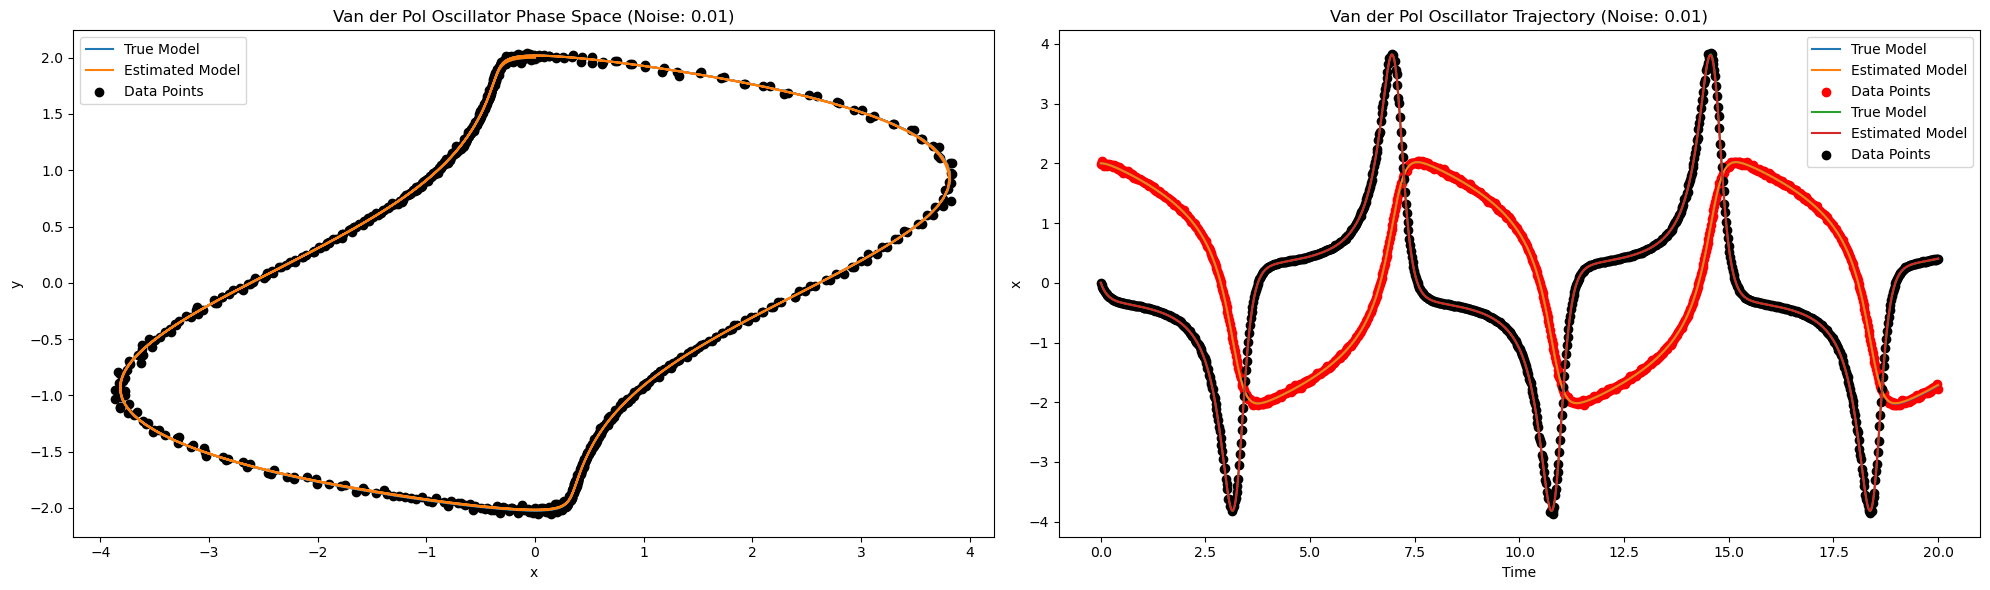

Noise Level: 0.01
Estimated mu: 1.9978530406951904
------
32/32 [==============================] - 0s 687us/step


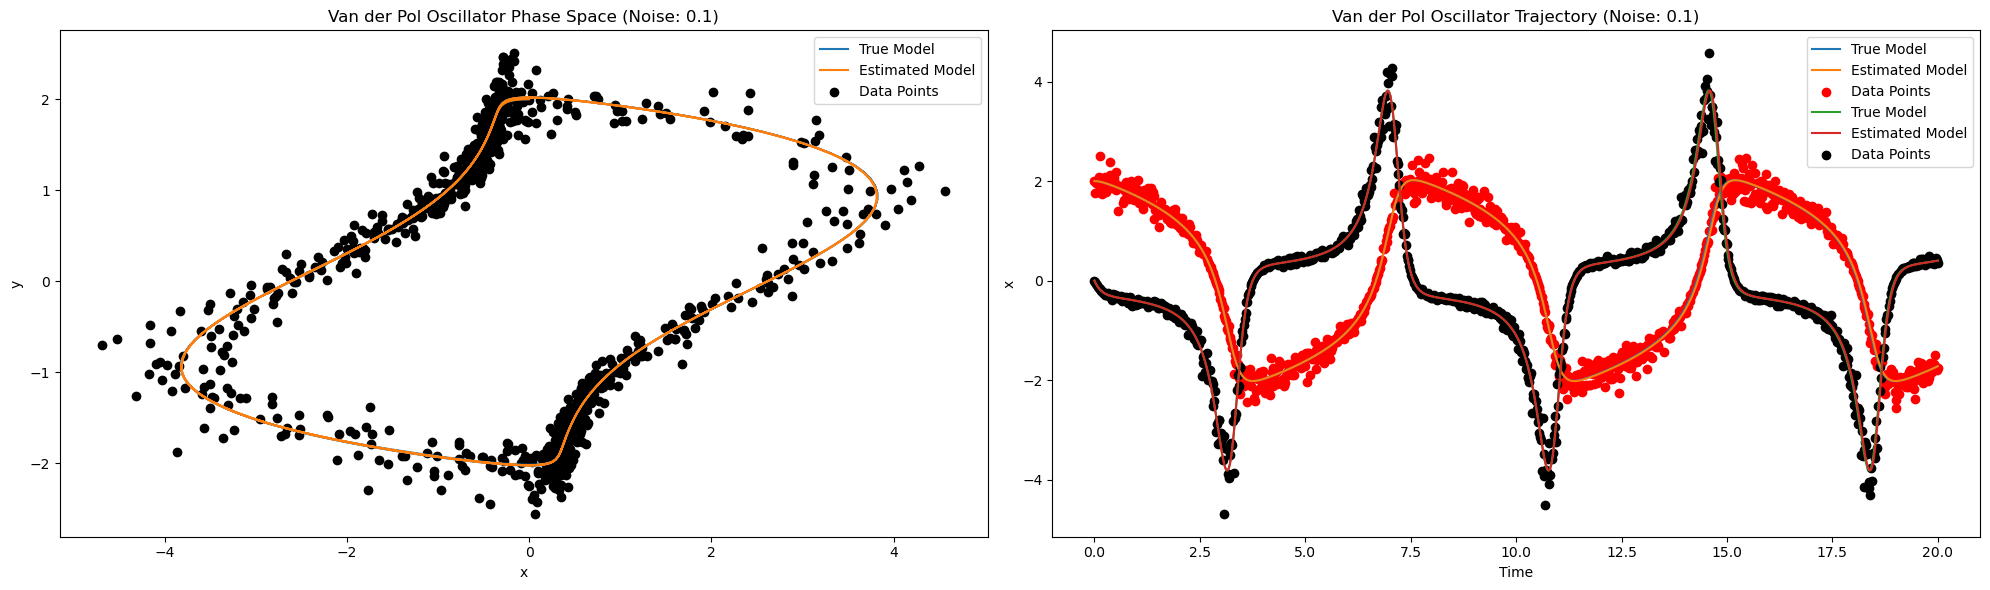

Noise Level: 0.1
Estimated mu: 1.9996342658996582
------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

for noise_std in noise_levels:
    # Create synthetic noisy data with multiplicative noise
    multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
    data = sol_true.y * multiplicative_noise

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Solve with true and estimated parameters
    sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
    sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

    # Plot phase space and trajectory
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Phase space plot
    ax1.plot(sol_true.y[1], sol_true.y[0], label='True Model')
    ax1.plot(sol_estimated.y[1], sol_estimated.y[0], label='Estimated Model')
    ax1.scatter(data[1], data[0], color='k', marker='o', label='Data Points')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_title(f'Van der Pol Oscillator Phase Space (Noise: {noise_std})')
    ax1.legend()

    # Trajectory plot
    ax2.plot(sol_true.t, sol_true.y[0], label='True Model')
    ax2.plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
    ax2.scatter(time_span, data[0], color='red', marker='o', label='Data Points')
    ax2.plot(sol_true.t, sol_true.y[1], label='True Model')
    ax2.plot(sol_estimated.t, sol_estimated.y[1], label='Estimated Model')
    ax2.scatter(time_span, data[1], color='k', marker='o', label='Data Points')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('x')
    ax2.set_title(f'Van der Pol Oscillator Trajectory (Noise: {noise_std})')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Noise Level: {noise_std}")
    print(f"Estimated mu: {mu_estimate}")
    print("------")


32/32 [==============================] - 0s 669us/step


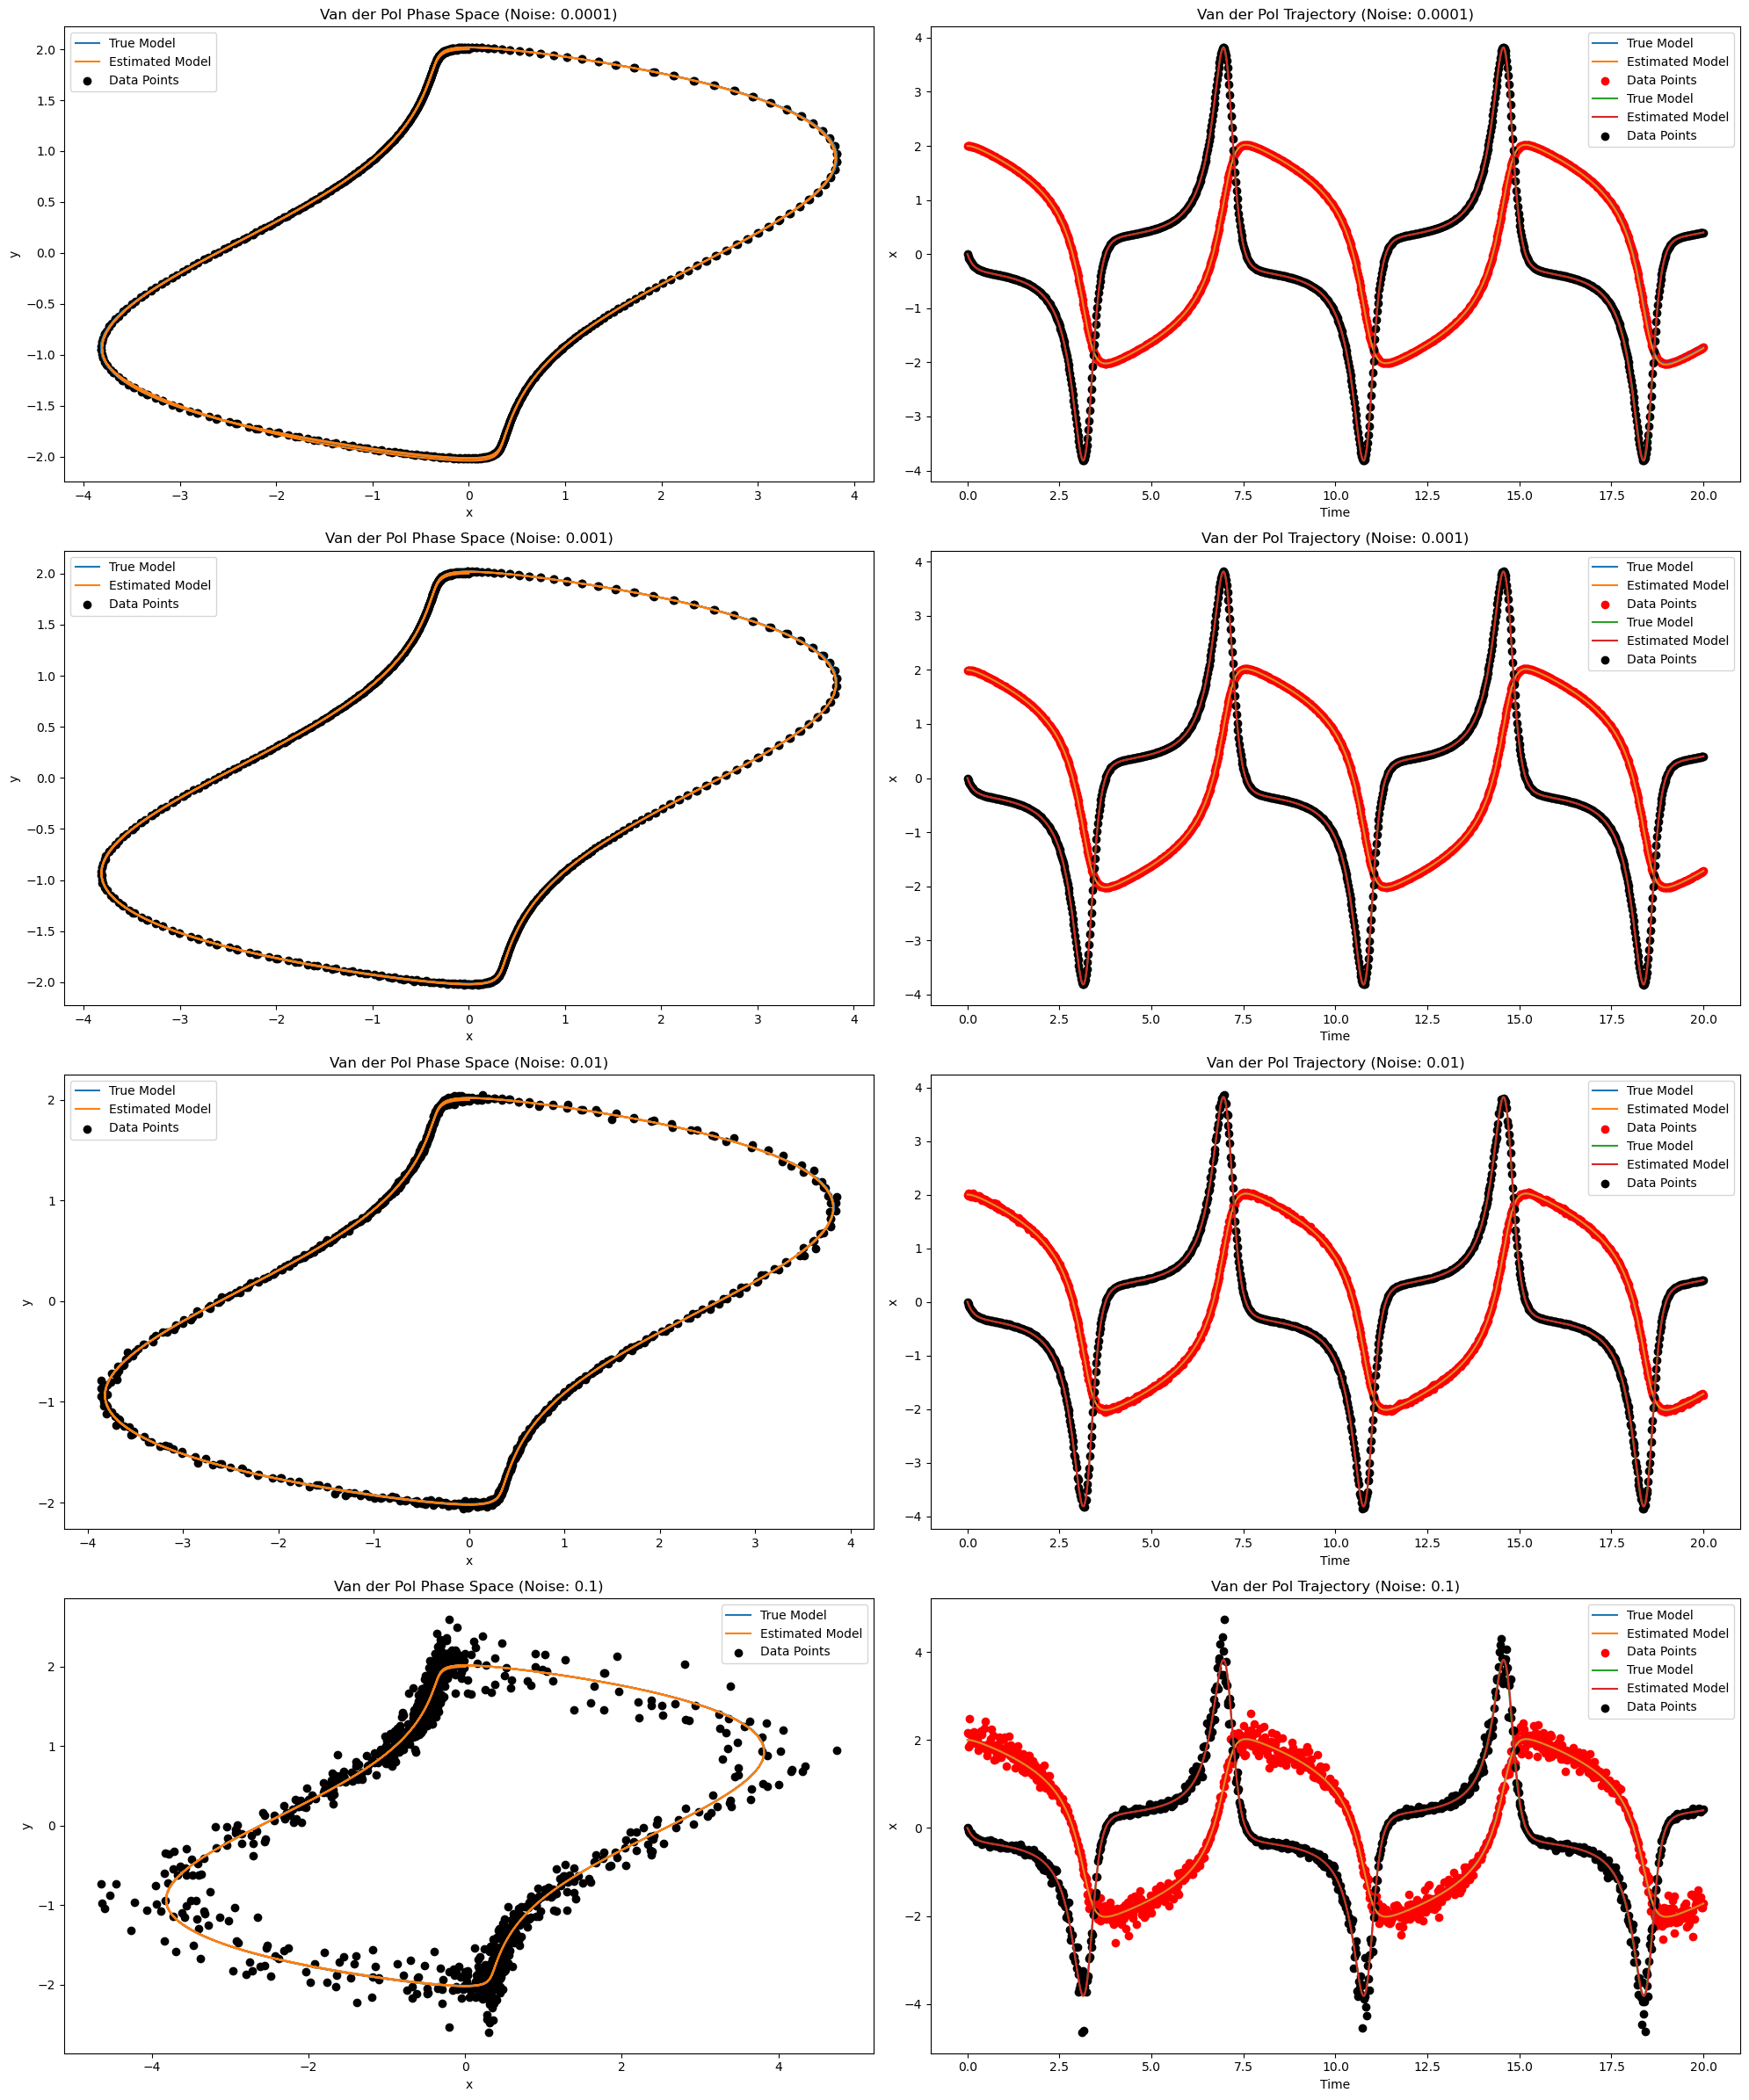

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

# Plot all phase space and trajectory plots together
fig, axs = plt.subplots(len(noise_levels), 2, figsize=(20, 6 * len(noise_levels)))

for i, noise_std in enumerate(noise_levels):
    # Create synthetic noisy data with multiplicative noise
    multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
    data = sol_true.y * multiplicative_noise

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Solve with true and estimated parameters
    sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
    sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

    # Phase space plot
    axs[i, 0].plot(sol_true.y[1], sol_true.y[0], label='True Model')
    axs[i, 0].plot(sol_estimated.y[1], sol_estimated.y[0], label='Estimated Model')
    axs[i, 0].scatter(data[1], data[0], color='k', marker='o', label='Data Points')
    axs[i, 0].set_xlabel('x')
    axs[i, 0].set_ylabel('y')
    axs[i, 0].set_title(f'van der Pol Oscillator: Phase Space (Noise: {noise_std})')
    axs[i, 0].legend()

    # Trajectory plot
    axs[i, 1].plot(sol_true.t, sol_true.y[0], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[0], color='red', marker='o', label='Data Points')
    axs[i, 1].plot(sol_true.t, sol_true.y[1], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[1], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[1], color='k', marker='o', label='Data Points')
    axs[i, 1].set_xlabel('Time')
    axs[i, 1].set_ylabel('x')
    axs[i, 1].set_title(f'van der Pol Oscillator: Trajectory (Noise: {noise_std})')
    axs[i, 1].legend()

plt.tight_layout()
plt.show()


32/32 [==============================] - 0s 678us/step
Average Estimated mu (Noise: 0.0001): [1.99946406]
32/32 [==============================] - 0s 627us/step
Average Estimated mu (Noise: 0.001): [1.99968123]
32/32 [==============================] - 0s 605us/step
Average Estimated mu (Noise: 0.01): [1.99969029]
32/32 [==============================] - 0s 637us/step
Average Estimated mu (Noise: 0.1): [2.00075681]
32/32 [==============================] - 0s 724us/step


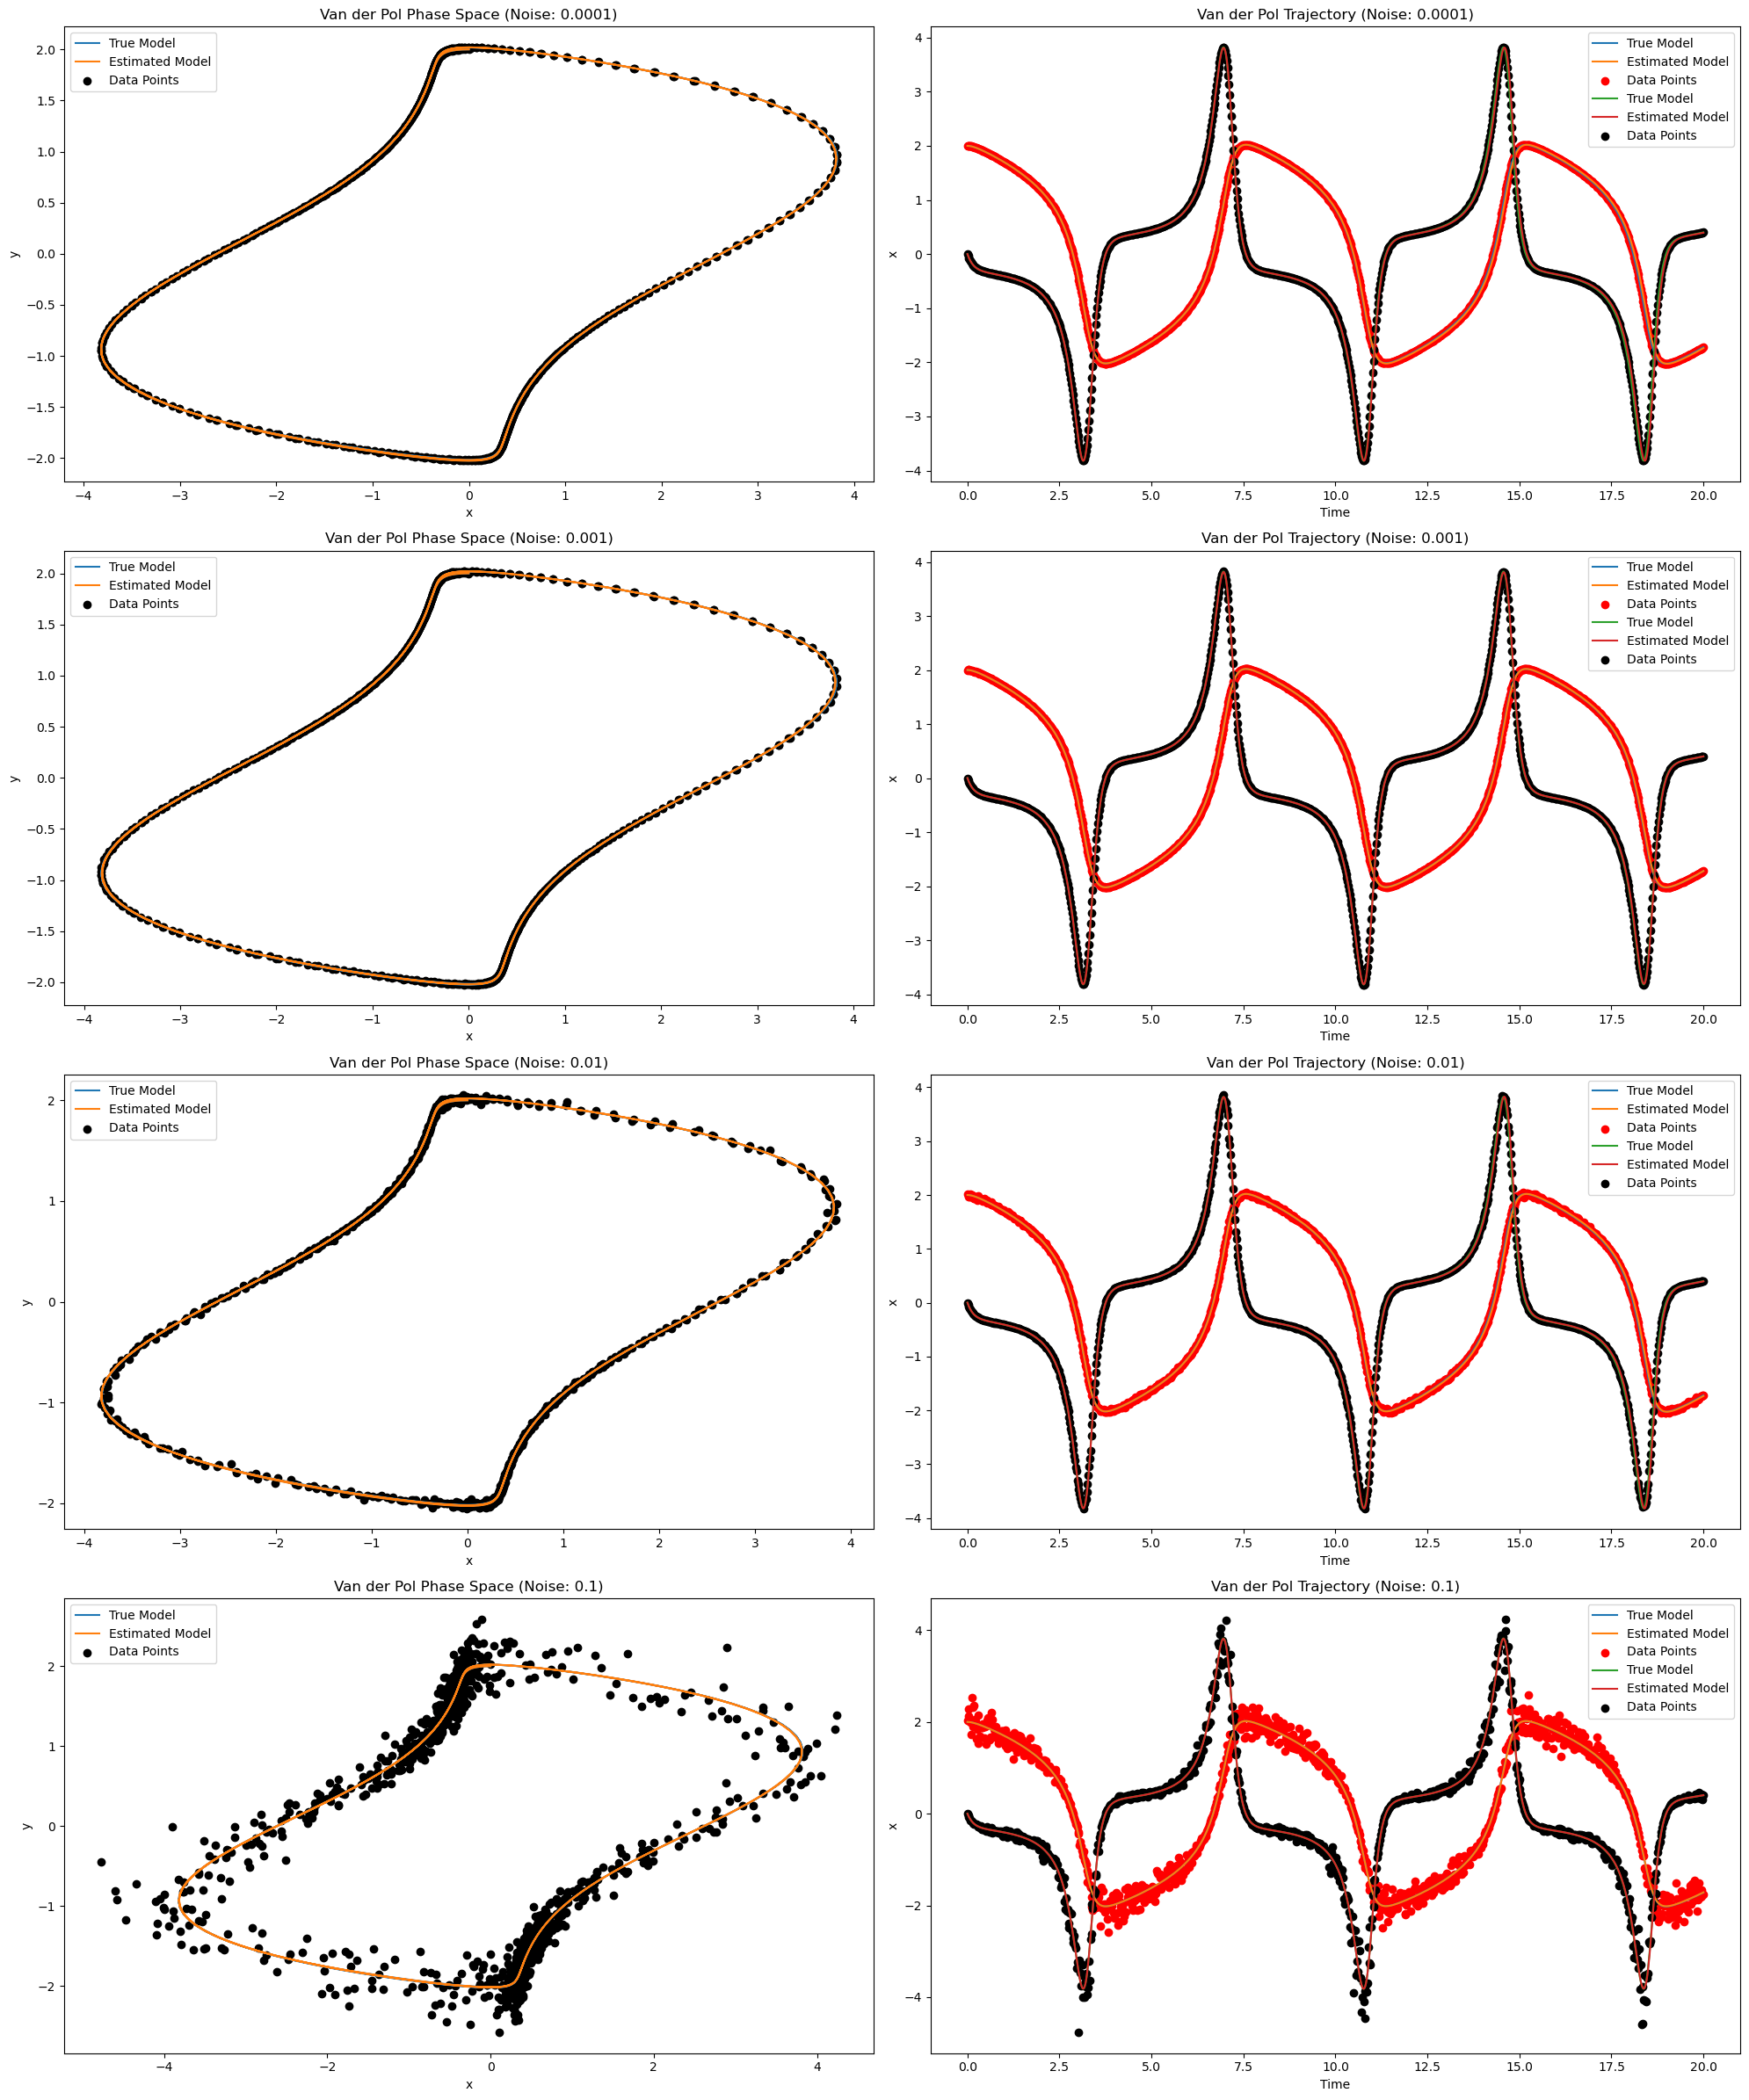

Final Average Estimated Parameters:
Noise: 0.0001 - Estimated mu: [1.99946406]
Noise: 0.001 - Estimated mu: [1.99968123]
Noise: 0.01 - Estimated mu: [1.99969029]
Noise: 0.1 - Estimated mu: [2.00075681]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

# Number of iterations
num_iterations = 10

# Store estimated parameters for each iteration
estimated_params_list = []

# Iterate over noise levels
for noise_std in noise_levels:
    estimated_params_sum = np.zeros(1)
    
    for _ in range(num_iterations):
        # Create synthetic noisy data with multiplicative noise
        multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
        data = sol_true.y * multiplicative_noise

        # Define the neural network model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
        ])

        # Compile the model with Huber loss
        huber_loss = tf.keras.losses.Huber(delta=1.0)
        model.compile(optimizer='adam', loss=huber_loss)

        # Train the neural network
        model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

        # Predict the estimated parameter using the trained neural network
        mu_estimate = model.predict(data.T).mean()
        
        estimated_params_sum += mu_estimate

    # Calculate average estimated parameter
    avg_estimated_param = estimated_params_sum / num_iterations
    estimated_params_list.append(avg_estimated_param)
    
    print(f"Average Estimated mu (Noise: {noise_std}): {avg_estimated_param}")

# Plot phase space and trajectory for the last iteration
fig, axs = plt.subplots(len(noise_levels), 2, figsize=(20, 6 * len(noise_levels)))

for i, noise_std in enumerate(noise_levels):
    # Create synthetic noisy data with multiplicative noise
    multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
    data = sol_true.y * multiplicative_noise

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Solve with true and estimated parameters
    sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
    sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

    # Phase space plot
    axs[i, 0].plot(sol_true.y[1], sol_true.y[0], label='True Model')
    axs[i, 0].plot(sol_estimated.y[1], sol_estimated.y[0], label='Estimated Model')
    axs[i, 0].scatter(data[1], data[0], color='k', marker='o', label='Data Points')
    axs[i, 0].set_xlabel('x')
    axs[i, 0].set_ylabel('y')
    axs[i, 0].set_title(f'Van der Pol Phase Space (Noise: {noise_std})')
    axs[i, 0].legend()

    # Trajectory plot
    axs[i, 1].plot(sol_true.t, sol_true.y[0], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[0], color='red', marker='o', label='Data Points')
    axs[i, 1].plot(sol_true.t, sol_true.y[1], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[1], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[1], color='k', marker='o', label='Data Points')
    axs[i, 1].set_xlabel('Time')
    axs[i, 1].set_ylabel('x')
    axs[i, 1].set_title(f'Van der Pol Trajectory (Noise: {noise_std})')
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

# Print the final estimated parameters for all noise levels
print("Final Average Estimated Parameters:")
for i, noise_std in enumerate(noise_levels):
    print(f"Noise: {noise_std} - Estimated mu: {estimated_params_list[i]}")


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

# Number of iterations
num_iterations = 10

# Store estimated parameters for each iteration
estimated_params_list = []

# Iterate over noise levels
for noise_std in noise_levels:
    estimated_params_sum = np.zeros(1)
    
    for _ in range(num_iterations):
        # Generate colored noise (pink noise)
        n = len(time_span)
        dt = time_span[1] - time_span[0]
        freq = np.fft.fftfreq(n, dt)
        power_spectrum = np.sqrt(1 / np.abs(freq))
        power_spectrum[0] = 0
        colored_noise = np.fft.ifft(np.fft.fft(np.random.normal(0, 1, n)) * power_spectrum).real

        # Adjust colored noise to match the length of the true solution
        desired_length = sol_true.y.shape[1]
        colored_noise = colored_noise[:desired_length]

        # Create synthetic noisy data with colored noise
        data = sol_true.y * colored_noise * noise_std

        # Define the neural network model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
        ])

        # Compile the model with Huber loss
        huber_loss = tf.keras.losses.Huber(delta=1.0)
        model.compile(optimizer='adam', loss=huber_loss)

        # Train the neural network
        model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

        # Predict the estimated parameter using the trained neural network
        mu_estimate = model.predict(data.T).mean()
        
        estimated_params_sum += mu_estimate

    # Calculate average estimated parameter
    avg_estimated_param = estimated_params_sum / num_iterations
    estimated_params_list.append(avg_estimated_param)
    
    print(f"Average Estimated mu (Noise: {noise_std}): {avg_estimated_param}")

# ... (rest of the code for plotting and printing)

# Print the final estimated parameters for all noise levels
print("Final Average Estimated Parameters:")
for i, noise_std in enumerate(noise_levels):
    print(f"Noise: {noise_std} - Estimated mu: {estimated_params_list[i]}")


/tmp/ipykernel_87589/1424684843.py:37: RuntimeWarning: divide by zero encountered in true_divide
  power_spectrum = np.sqrt(1 / np.abs(freq))


32/32 [==============================] - 0s 680us/step
Average Estimated mu (Noise: 0.0001): [2.00034885]
32/32 [==============================] - 0s 671us/step
Average Estimated mu (Noise: 0.001): [1.99980856]
32/32 [==============================] - 0s 666us/step
Average Estimated mu (Noise: 0.01): [2.00032998]
32/32 [==============================] - 0s 682us/step
Average Estimated mu (Noise: 0.1): [1.99989827]
Final Average Estimated Parameters:
Noise: 0.0001 - Estimated mu: [2.00034885]
Noise: 0.001 - Estimated mu: [1.99980856]
Noise: 0.01 - Estimated mu: [2.00032998]
Noise: 0.1 - Estimated mu: [1.99989827]


32/32 [==============================] - 0s 636us/step


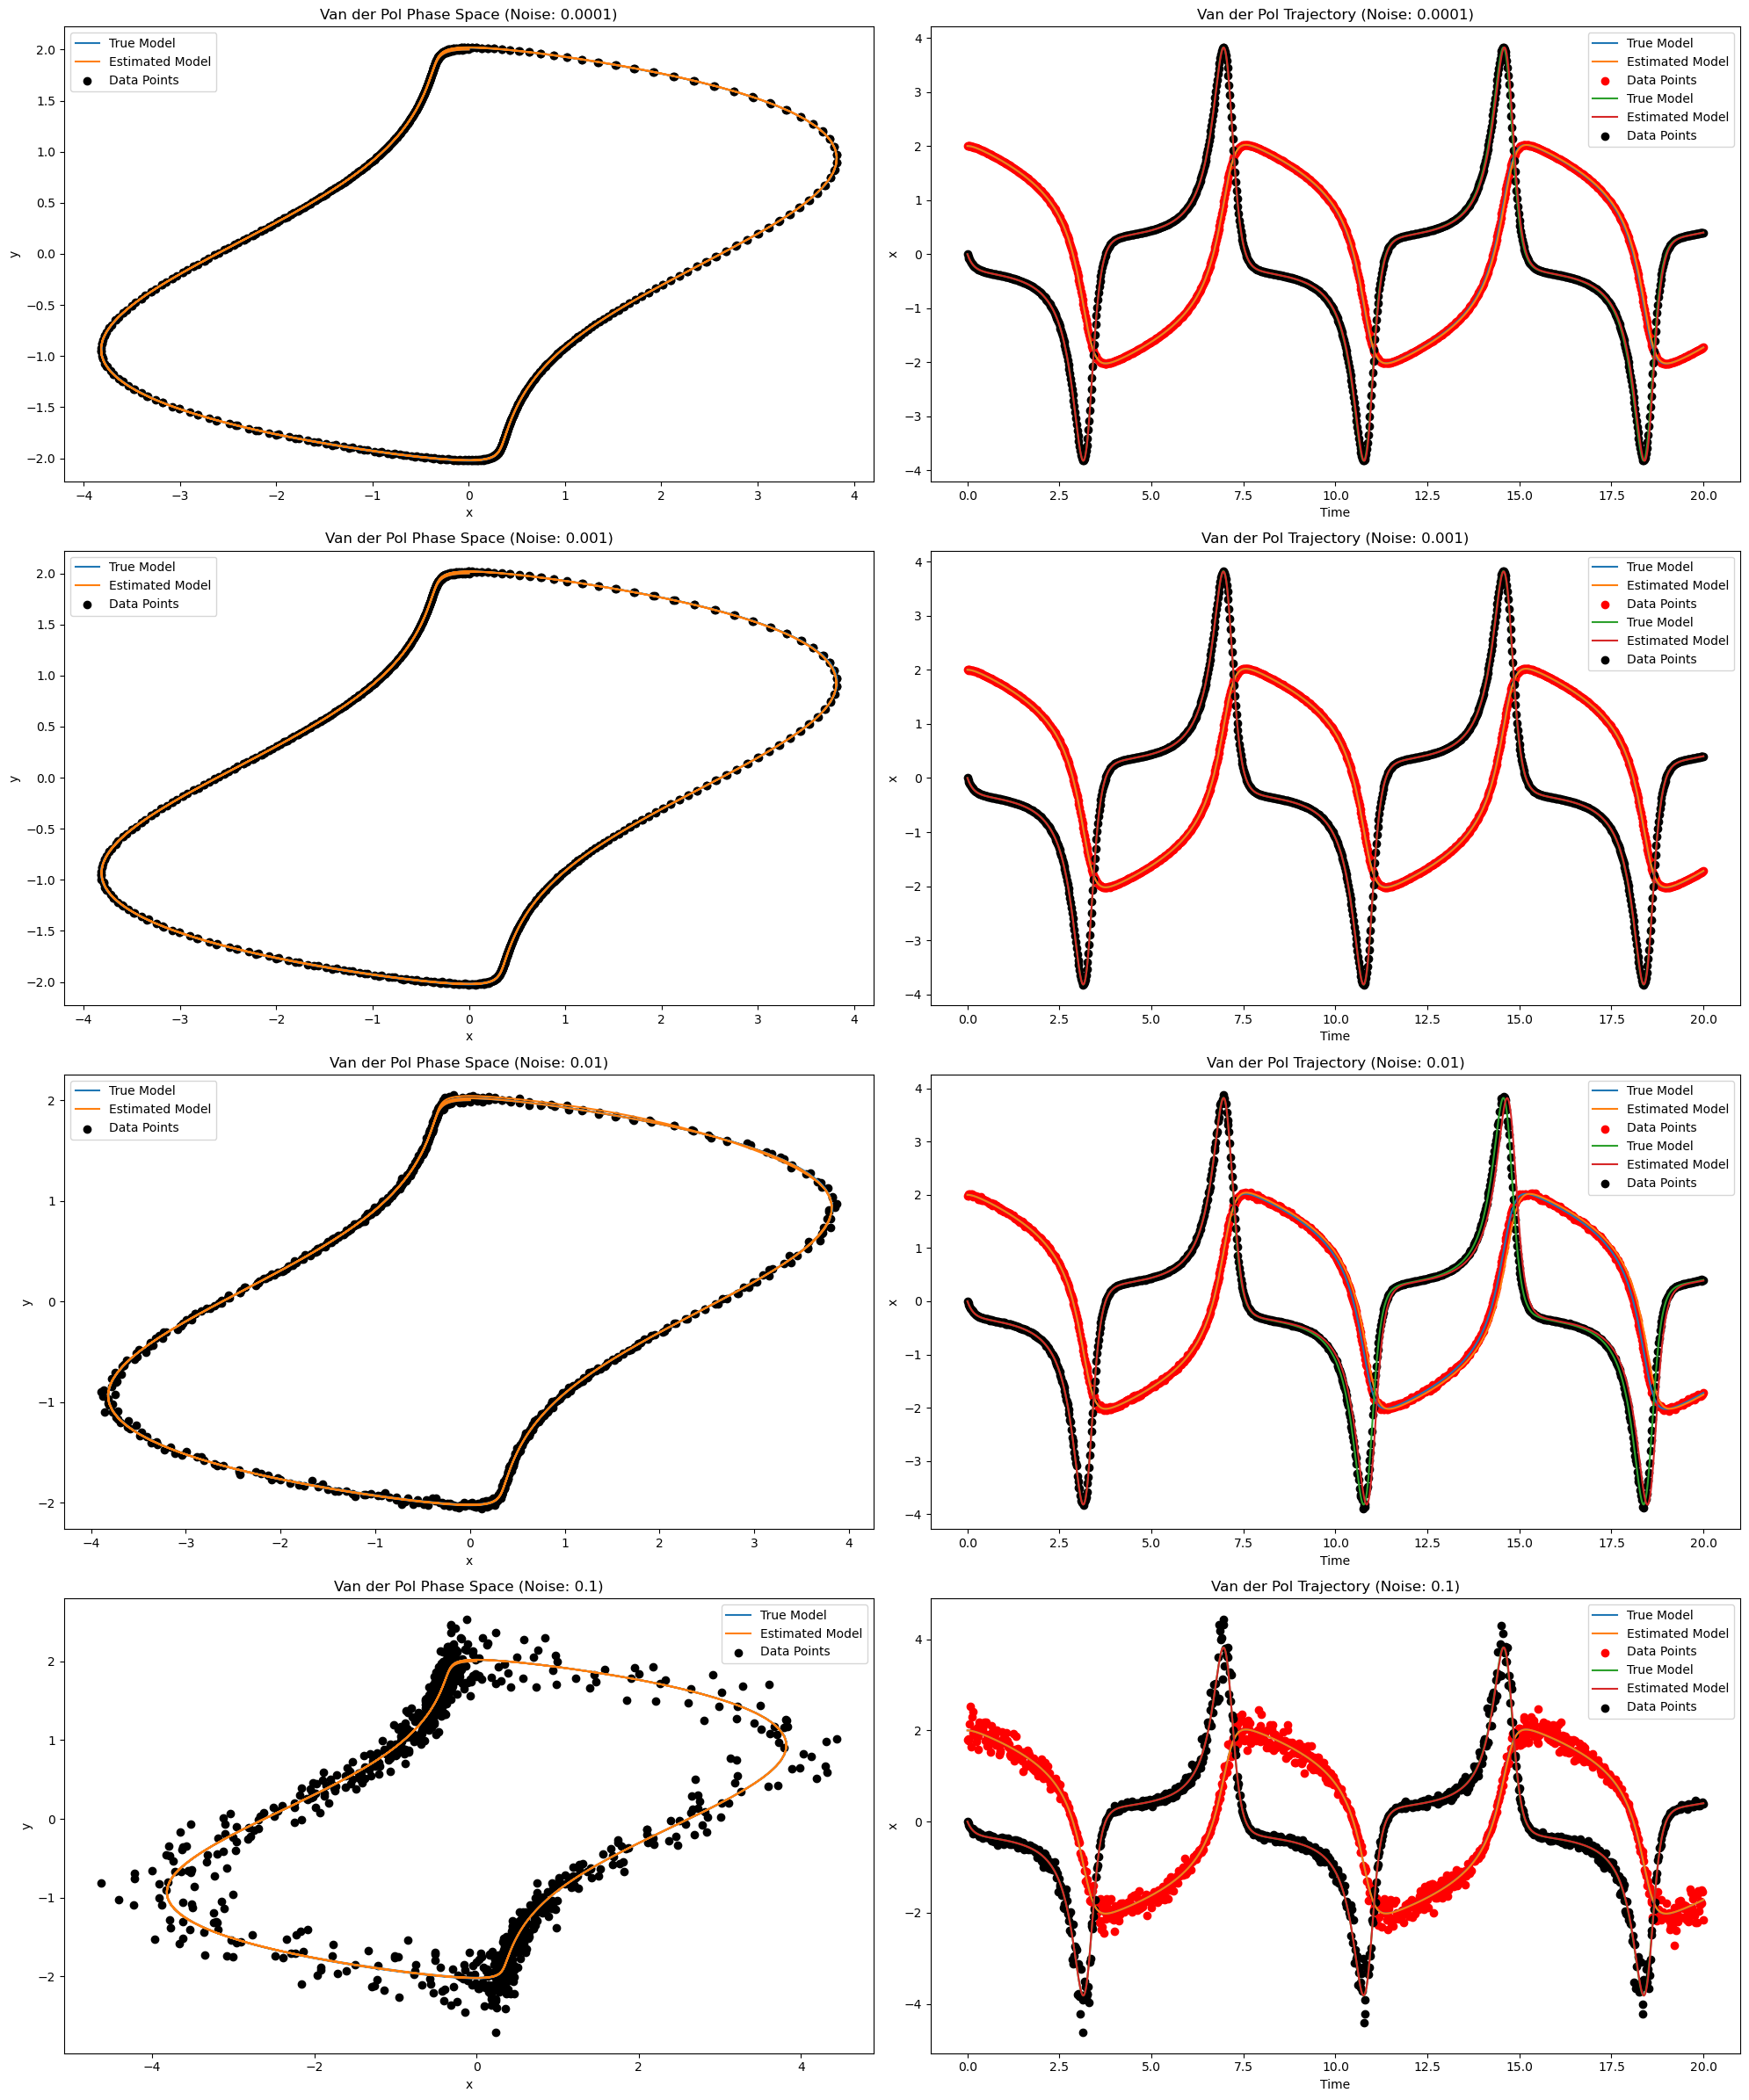

In [10]:
# Plot phase space and trajectory for the last iteration
fig, axs = plt.subplots(len(noise_levels), 2, figsize=(20, 6 * len(noise_levels)))

for i, noise_std in enumerate(noise_levels):
    # Create synthetic noisy data with multiplicative noise
    multiplicative_noise = np.random.lognormal(mean=0, sigma=noise_std, size=sol_true.y.shape)
    data = sol_true.y * multiplicative_noise

    # Define the neural network model
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
    ])

    # Compile the model with Huber loss
    huber_loss = tf.keras.losses.Huber(delta=1.0)
    model.compile(optimizer='adam', loss=huber_loss)

    # Train the neural network
    model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

    # Predict the estimated parameter using the trained neural network
    mu_estimate = model.predict(data.T).mean()

    # Solve with true and estimated parameters
    sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)
    sol_estimated = solve_ivp(lambda t, z: van_der_pol(t, z, mu_estimate), [0, 20], initial_conditions, t_eval=time_span)

    # Phase space plot
    axs[i, 0].plot(sol_true.y[1], sol_true.y[0], label='True Model')
    axs[i, 0].plot(sol_estimated.y[1], sol_estimated.y[0], label='Estimated Model')
    axs[i, 0].scatter(data[1], data[0], color='k', marker='o', label='Data Points')
    axs[i, 0].set_xlabel('x')
    axs[i, 0].set_ylabel('y')
    axs[i, 0].set_title(f'Van der Pol Phase Space (Noise: {noise_std})')
    axs[i, 0].legend()

    # Trajectory plot
    axs[i, 1].plot(sol_true.t, sol_true.y[0], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[0], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[0], color='red', marker='o', label='Data Points')
    axs[i, 1].plot(sol_true.t, sol_true.y[1], label='True Model')
    axs[i, 1].plot(sol_estimated.t, sol_estimated.y[1], label='Estimated Model')
    axs[i, 1].scatter(time_span, data[1], color='k', marker='o', label='Data Points')
    axs[i, 1].set_xlabel('Time')
    axs[i, 1].set_ylabel('x')
    axs[i, 1].set_title(f'Van der Pol Trajectory (Noise: {noise_std})')
    axs[i, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.integrate import solve_ivp

# Define the Van der Pol ODE model
def van_der_pol(t, z, mu):
    x, y = z
    dxdt = y
    dydt = mu * (1 - x**2) * y - x
    return [dxdt, dydt]

# Generate synthetic data with known parameters
mu_true = 2.0
initial_conditions = [2, 0]
time_span = np.linspace(0, 20, 1000)
sol_true = solve_ivp(lambda t, z: van_der_pol(t, z, mu_true), [0, 20], initial_conditions, t_eval=time_span)

# Noise levels to test
noise_levels = [0.0001, 0.001, 0.01, 0.1]

# Number of iterations
num_iterations = 10

# Store estimated parameters for each iteration
estimated_params_list = []

# Iterate over noise levels
for noise_std in noise_levels:
    estimated_params_sum = np.zeros(1)
    
    for _ in range(num_iterations):
        # Generate colored noise (pink noise)
        n = len(time_span)
        dt = time_span[1] - time_span[0]
        freq = np.fft.fftfreq(n, dt)
        power_spectrum = np.sqrt(1 / np.abs(freq))
        power_spectrum[0] = 0
        colored_noise = np.fft.ifft(np.fft.fft(np.random.normal(0, 1, n)) * power_spectrum).real

        # Adjust colored noise to match the length of the true solution
        desired_length = sol_true.y.shape[1]
        colored_noise = colored_noise[:desired_length]

        # Create synthetic noisy data with colored noise
        data = sol_true.y * colored_noise * noise_std

        # Define the neural network model
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(data.shape[0],)),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dense(1)  # Output layer for parameter estimation (mu)
        ])

        # Compile the model with Huber loss
        huber_loss = tf.keras.losses.Huber(delta=1.0)
        model.compile(optimizer='adam', loss=huber_loss)

        # Train the neural network
        model.fit(data.T, np.array([mu_true] * data.shape[1]), epochs=1000, verbose=0)

        # Predict the estimated parameter using the trained neural network
        mu_estimate = model.predict(data.T).mean()
        
        estimated_params_sum += mu_estimate

    # Calculate average estimated parameter
    avg_estimated_param = estimated_params_sum / num_iterations
    estimated_params_list.append(avg_estimated_param)
    
    print(f"Average Estimated mu (Noise: {noise_std}): {avg_estimated_param}")

# ... (rest of the code for plotting and printing)

# Print the final estimated parameters for all noise levels
print("Final Average Estimated Parameters:")
for i, noise_std in enumerate(noise_levels):
    print(f"Noise: {noise_std} - Estimated mu: {estimated_params_list[i]}")
